[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ushaloy/SAVE-LEWS/blob/main/notebooks/02_thailand_step2_consistency_vs_skill.ipynb)

# SAVE-LEWS Thailand — Step 2: lateral terms, event-weighted residual, and the physics-vs-skill trade-off

Questions tested (training still on **one storm**, Dev108 6 Nov 2025; everything else unseen; rain nowcast = **oracle** where labelled):
1. Does a **convergent lateral inflow** (γ × effective rain through a linear reservoir, released at depth z_l) and/or **lateral drainage** (λ_out·K(θ)) close the sensor water budget?
2. Does an **event-weighted residual** (steps where the sensor moves get up to ~100× weight) make the network genuinely Richards-consistent?
3. Does the added structure beat the 1-D model on held-out storms — and does the **calibrated physics alone** (implicit solver, no network) do as well as the networks? (**H1**)

| Run | Structure | Residual | Seeds |
|---|---|---|---|
| A, B, C | step-1 configs (weak / strong residual / no physics) | uniform or storm-weighted | 1 |
| **M0** | 1-D + bypass | event-weighted, scale 1e-6 s⁻¹ | 2 |
| **M1** | M0 + lateral inflow + lateral drainage | event-weighted, scale 1e-6 s⁻¹ | 2 |

`TRAIN=False` loads the checkpoints shipped with this notebook; `RUN_SOLVER=False` loads the stored physics-only results (the solver pass takes ~15 min per run on CPU).

In [1]:
import os, sys, subprocess, json, warnings
REPO_URL = 'https://github.com/Ushaloy/SAVE-LEWS'   # <-- set this to your GitHub repository before running in Colab
def _repo_root():
    here = os.getcwd()
    for c in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here)), '/content/SAVE-LEWS', os.path.join(here, 'SAVE-LEWS')]:
        if os.path.exists(os.path.join(c, 'thailand', 'data_pipeline.py')):
            return c
    dst = '/content/SAVE-LEWS' if 'google.colab' in sys.modules else os.path.join(here, 'SAVE-LEWS')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, dst], check=True)
    return dst
ROOT = _repo_root(); os.chdir(os.path.join(ROOT, 'thailand')); sys.path.insert(0, os.getcwd())
for _pkg, _mod in [('numpyro', 'numpyro'), ('optax', 'optax'), ('openpyxl', 'openpyxl')]:
    try: __import__(_mod)
    except ImportError: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg], check=True)
DATA = '../data/thailand'
print('repository:', ROOT, '| working folder:', os.getcwd())
TRAIN, RUN_SOLVER, ITERS = False, False, 1500
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); torch.set_num_threads(2)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repository: /content/SAVE-LEWS | working folder: /content/SAVE-LEWS/thailand


## 1. Code (data pipeline, physics with optional lateral terms, solver, training)

In [2]:
"""Shared data pipeline: Dev107/108 -> 5-min grid with reset-aware rain increments."""
import numpy as np, pandas as pd
TIP_MM = 0.2794

def load_device(path, temp_coef=-0.0009, tref=None):
    d = pd.read_csv(path)
    d['t'] = pd.to_datetime(d.timestamp, format='%m/%d/%Y %H:%M')
    d = d.sort_values('t', kind='stable').groupby('t').agg(
        rain=('rain', 'last'), soil=('soil', 'mean'), temp=('temp', 'mean'))
    c = d.rain.values
    dif = np.diff(c, prepend=c[0])
    inc = np.clip(dif, 0, None)
    # a descent = interpolated hourly reset; the true counter restarted at 0,
    # so the bottom value of the descent is already new-hour rain
    bottom = (dif < 0) & (np.r_[dif[1:], 0] >= 0)
    inc = inc + c * bottom
    d['rain_inc'] = inc
    g = pd.DataFrame({
        'rain': d.rain_inc.resample('5min').sum(min_count=1),   # empty bin -> NaN (missing, not dry)
        'theta_raw': d.soil.resample('5min').mean(),
        'temp': d.temp.resample('5min').mean(),
        'n_raw': d.soil.resample('5min').count()})
    tref = g.temp.mean() if tref is None else tref
    # sensor reads low when warm: remove the artifact
    g['theta'] = g.theta_raw - temp_coef * (g.temp - tref)
    return g

def storm_catalogue(g, min_total=10.0, dry_gap_h=6.0):
    """Storms = rain clusters separated by >= dry_gap_h hours with no rain; keep total >= min_total."""
    r = g.rain.fillna(0)
    wet = r[r > 0].index
    storms, start, last, tot = [], None, None, 0.0
    for t in wet:
        if start is None or (t - last) > pd.Timedelta(hours=dry_gap_h):
            if start is not None: storms.append((start, last, tot))
            start, tot = t, 0.0
        tot += r[t]; last = t
    if start is not None: storms.append((start, last, tot))
    s = pd.DataFrame(storms, columns=['start', 'end', 'rain_mm'])
    return s[s.rain_mm >= min_total].reset_index(drop=True)


In [3]:
"""
Step 1: discrete-time Richards profile PINN stepped in real time (dt = 5 min).

State: theta(z) on a 30-cell column, dz = 4 cm, 0-1.2 m (cell centres 2,6,...,118 cm;
the 30 cm sensor is cell 7, the 1.0 m failure plane is the mean of cells 24/25).

Per step k -> k+1 the network proposes the whole profile theta^{k+1}. It is trained with
  (a) data loss on the 30 cm cell (multi-step open-loop forecasts, 30/60/120 min), and
  (b) the implicit (backward-Euler) Richards residual of its own proposal
      R_i = (theta_i^{k+1} - theta_i^k)/dt - [(q_{i-1/2} - q_{i+1/2})/dz + S_i]
      with Darcy fluxes q from van Genuchten K(theta^{k+1}), h(theta^{k+1}) (z down, q down +),
      surface flux = matrix share of effective rain, free drainage at 1.2 m,
      S_i = macropore (bypass) delivery of effective rain around depth z_b.
Effective rain passes an interception/initial-abstraction store of capacity c (learned),
which empties with time constant tau between storms.
Learned physical parameters: Ks, alpha, n, c, tau, bypass fraction beta, z_b, bypass width.
theta_r, theta_s fixed (Dev108: 0.05 / 0.55).
"""
import math, numpy as np, torch, torch.nn as nn, torch.nn.functional as F

DT = 300.0                       # s
DZ = 0.04                        # m
NZ = 30
Z = (torch.arange(NZ) + 0.5) * DZ  # cell centres, m
I_OBS = 7                        # z = 0.30 m
I_FAIL = (24, 25)                # z = 0.98 / 1.02 -> 1.0 m

def bounded(raw, lo, hi, log=False):
    s = torch.sigmoid(raw)
    if log:
        return torch.exp(math.log(lo) + s * (math.log(hi) - math.log(lo)))
    return lo + s * (hi - lo)

def inv_bounded(v, lo, hi, log=False):
    if log:
        s = (math.log(v) - math.log(lo)) / (math.log(hi) - math.log(lo))
    else:
        s = (v - lo) / (hi - lo)
    s = min(max(s, 1e-4), 1 - 1e-4)
    return math.log(s / (1 - s))

# (name, lo, hi, log, init)   a priori: Ks 0.0043 m/h, alpha 5.9 1/m, n 1.48
PARAM_SPEC = [
    ('Ks_mph', 1e-4, 1.0, True, 0.0043),
    ('alpha',  0.5, 20.0, True, 5.9),
    ('n',      1.1, 3.0, False, 1.48),
    ('c_mm',   0.0, 15.0, False, 5.0),    # interception / initial-abstraction capacity
    ('tau_h',  1.0, 72.0, True, 6.0),     # store emptying time constant
    ('beta',   0.0, 1.0, False, 0.5),     # bypass fraction of effective rain
    ('zb',     0.05, 1.0, False, 0.30),   # bypass delivery depth
    ('wb',     0.02, 0.5, True, 0.10),    # bypass delivery width
]

# convergent lateral inflow (linear reservoir fed by gamma x effective rain, released around z_l)
# and lateral drainage sink lam_out * K(theta)  [1/m * m/s = 1/s]
LATERAL_SPEC = [
    ('gamma',     0.0, 5.0, False, 0.5),
    ('tau_lat_h', 0.05, 24.0, True, 0.5),
    ('zl',        0.05, 1.0, False, 0.30),
    ('wl',        0.02, 0.5, True, 0.08),
    ('lam_out',   0.01, 1e4, True, 1.0),
]

# fast (macropore) domain at the probe: store F (mm) fed by beta x effective rain,
# drains out of the column (tau_fd) and exchanges into the matrix around z_b (tau_fx);
# the probe reads theta_m + (theta_s - theta_m) * tanh(kappa * F)
FAST_SPEC = [
    ('kappa',    1e-3, 1.0, True, 0.03),
    ('tau_fd_h', 0.05, 12.0, True, 0.5),
    ('tau_fx_h', 0.05, 48.0, True, 2.0),
]

# bounded fast domain: macropore water can add at most phi_f (macropore porosity, <= 5 %) to the probe reading
BOUNDED_SPEC = [('phi_f', 0.005, 0.05, False, 0.02)]

class Physics(nn.Module):
    def __init__(self, theta_r=0.05, theta_s=0.55, init=None, lateral=False, fast=False, bounded=False):
        super().__init__()
        self.tr, self.ts = theta_r, theta_s
        self.lateral, self.fast, self.bounded = lateral, fast, bounded
        spec = (PARAM_SPEC + (LATERAL_SPEC if lateral else []) + (FAST_SPEC if fast else [])
                + (BOUNDED_SPEC if bounded else []))
        init = init or {}
        self.raw = nn.ParameterDict({
            n: nn.Parameter(torch.tensor(inv_bounded(init.get(n, v0), lo, hi, lg)))
            for n, lo, hi, lg, v0 in spec})
        self.spec = {n: (lo, hi, lg) for n, lo, hi, lg, _ in spec}

    def p(self, name):
        lo, hi, lg = self.spec[name]
        return bounded(self.raw[name], lo, hi, lg)

    def values(self):
        return {n: float(self.p(n)) for n in self.spec}

    # van Genuchten-Mualem
    def Se(self, th):
        return ((th - self.tr) / (self.ts - self.tr)).clamp(1e-3, 0.999)

    def h(self, th):                       # pressure head, m (negative)
        n = self.p('n'); m = 1 - 1 / n; a = self.p('alpha')
        lg = (-(1 / m) * torch.log(self.Se(th))).clamp(max=25.0)   # overflow-safe
        return -(1 / a) * torch.expm1(lg).clamp_min(1e-12) ** (1 / n)

    def K(self, th):                       # m/s
        n = self.p('n'); m = 1 - 1 / n; se = self.Se(th)
        Ks = self.p('Ks_mph') / 3600.0
        return Ks * se.sqrt() * (1 - (1 - se ** (1 / m)) ** m) ** 2

    def bypass_weights(self):
        w = torch.exp(-0.5 * ((Z - self.p('zb')) / self.p('wb')) ** 2)
        return w / w.sum()

    def interception(self, store, rain_mm):
        """store (B,), rain_mm (B,) for one 5-min step -> (new store, effective rain mm)."""
        c = self.p('c_mm')
        s = store * torch.exp(-DT / 3600.0 / self.p('tau_h')) + rain_mm
        eff = F.softplus(s - c, beta=20.0)          # smooth overflow
        return s - eff, eff

    def gauss(self, zc, w):
        g = torch.exp(-0.5 * ((Z - zc) / w) ** 2)
        return g / g.sum()

    def drive(self, rain):
        """rain (T,) or (W,T) mm/5min -> drive (T,C) or (W,T,C):
        [effective rain, lateral inflow, (fast exchange, fast store F)] in mm per 5-min step."""
        if rain.dim() == 2:
            return self._drive(rain)
        return self._drive(rain[None])[0]

    def fast_decay(self):
        kd, kx = 1 / self.p('tau_fd_h'), 1 / self.p('tau_fx_h')
        return torch.exp(-DT / 3600.0 * (kd + kx)), kx / (kd + kx)

    def _drive(self, rain):
        W = rain.shape[0]
        store = torch.zeros(W); L = torch.zeros(W); Fs = torch.zeros(W); out = []
        if self.lateral:
            dec = torch.exp(-DT / 3600.0 / self.p('tau_lat_h')); gam = self.p('gamma')
        if self.fast:
            fdec, fx = self.fast_decay(); beta = self.p('beta')
        for k in range(rain.shape[1]):
            store, e = self.interception(store, rain[:, k])
            if self.lateral:
                rel = L * (1 - dec); L = L - rel + gam * e
            else:
                rel = torch.zeros(W)
            if self.fast:
                lost = Fs * (1 - fdec); exch = lost * fx; Fs = Fs - lost + beta * e
                out.append(torch.stack([e, rel, exch, Fs], -1))
            else:
                out.append(torch.stack([e, rel], -1))
        return torch.stack(out, 1)

    def sensor(self, th_obs_cell, F_mm):
        """probe reading from matrix theta at the probe cell and fast-domain store (identity if no fast domain)."""
        if not self.fast:
            return th_obs_cell
        if self.bounded:
            return (th_obs_cell + self.p('phi_f') * torch.tanh(self.p('kappa') * F_mm)).clamp(max=self.ts)
        return th_obs_cell + (self.ts - th_obs_cell) * torch.tanh(self.p('kappa') * F_mm)

    def sensor_inverse(self, obs, F_mm):
        """matrix theta at the probe consistent with an observation."""
        if not self.fast:
            return obs
        if self.bounded:
            return obs - self.p('phi_f') * torch.tanh(self.p('kappa') * F_mm)
        t = torch.tanh(self.p('kappa') * F_mm)
        return (obs - self.ts * t) / (1 - t).clamp_min(1e-3)

    def forcing(self, th, drive):
        """surface flux q0 (B,) and internal source S (B,NZ) in m/s, limited by free storage.
        drive (B,2) = [effective rain mm, lateral inflow mm] per 5-min step (legacy: (B,) rain only)."""
        if drive.dim() == 1:
            drive = torch.stack([drive, torch.zeros_like(drive)], 1)
        eff_mm, lat_mm = drive[:, 0], drive[:, 1]
        p = eff_mm / 1000.0 / DT                              # m/s
        room = 1 - self.Se(th)
        avail = room / (room + 0.02)                          # ~1 unless near saturation; excess -> runoff
        beta = self.p('beta')
        q0 = (1 - beta) * p * avail[:, 0]
        if self.fast:   # macropore water enters the matrix by delayed exchange, not instantly
            S = (drive[:, 2] / 1000.0 / DT)[:, None] * self.bypass_weights()[None, :] * avail / DZ
        else:
            S = beta * p[:, None] * self.bypass_weights()[None, :] * avail / DZ
        if self.lateral:
            S = S + (lat_mm / 1000.0 / DT)[:, None] * self.gauss(self.p('zl'), self.p('wl'))[None, :] * avail / DZ
        return q0, S

    def rhs(self, th, q0, S):
        """d theta/dt (B,NZ) plus flux divergence term, evaluated at profile th."""
        K = self.K(th); h = self.h(th)
        Kf = 0.5 * (K[:, 1:] + K[:, :-1])
        q_int = Kf * (1 - (h[:, 1:] - h[:, :-1]) / DZ)       # downward positive
        q = torch.cat([q0[:, None], q_int, K[:, -1:]], dim=1) # (B, NZ+1), free drainage at bottom
        div = (q[:, :-1] - q[:, 1:]) / DZ                      # -dq/dz
        f = div + S
        if self.lateral:
            f = f - self.p('lam_out') * K                      # lateral (slope-parallel) drainage
        return f, div, q

class Stepper(nn.Module):
    """1-D conv net proposing theta^{k+1} from theta^k and forcing; storage-bounded output."""
    def __init__(self, phys, width=32):
        super().__init__()
        self.phys = phys
        cin = 6
        self.net = nn.Sequential(
            nn.Conv1d(cin, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, 2, 1))
        nn.init.zeros_(self.net[-1].weight)
        with torch.no_grad():
            self.net[-1].bias.fill_(-6.0)

    def forward(self, th, drive):
        ph = self.phys
        q0, S = ph.forcing(th, drive)
        f_expl, _, _ = ph.rhs(th, q0, S)
        B = th.shape[0]
        se = ph.Se(th)
        x = torch.stack([
            se,
            torch.log10(-ph.h(th) + 1e-4) / 3,
            Z[None, :].expand(B, -1),
            (q0[:, None] * DT / DZ * 10).expand(-1, NZ),     # surface input, scaled
            S * DT * 10,
            torch.tanh(f_expl * DT * 20),                   # explicit physics hint (bounded)
        ], dim=1)
        a = self.net(x)
        tr, ts = ph.tr, ph.ts
        th_new = th + (ts - th) * torch.sigmoid(a[:, 0]) - (th - tr) * torch.sigmoid(a[:, 1])
        return th_new, q0, S

def residual(phys, th_old, th_new, q0, S):
    f, div, q = phys.rhs(th_new, q0, S)
    dthdt = (th_new - th_old) / DT
    return dthdt - f, dthdt, div, S


In [4]:
"""Independent backward-Euler Richards solver (Newton, dense Jacobian per column) with the
same parameterisation/forcing as the PINN. Used to (i) verify that the PINN's profile is a
Richards solution and (ii) as a physics-only baseline."""
import torch
from torch.func import jacrev, vmap

@torch.no_grad()
def be_step(phys, th, eff_mm, nsub=2, newton=8):
    """th (B,NZ) -> th_new (B,NZ); forcing frozen at start of step as in the PINN."""
    q0, S = phys.forcing(th, eff_mm)
    dt = DT / nsub
    lo, hi = phys.tr + 1e-4, phys.ts - 1e-4
    for _ in range(nsub):
        old = th
        def G(x, xo, q0_, S_):
            f, _, _ = phys.rhs(x[None], q0_[None], S_[None])
            return x - xo - dt * f[0]
        x = old.clone()
        for _ in range(newton):
            r = vmap(G)(x, old, q0, S)
            J = vmap(jacrev(G))(x, old, q0, S)
            dx = torch.linalg.solve(J, -r.unsqueeze(-1)).squeeze(-1)
            x = (x + dx.clamp(-0.05, 0.05)).clamp(lo, hi)
        th = x
    return th

@torch.no_grad()
def solver_forecast(phys, th0, eff_seq):
    th = th0; traj = []
    for j in range(eff_seq.shape[1]):
        th = be_step(phys, th, eff_seq[:, j]); traj.append(th)
    return torch.stack(traj, 1)


In [5]:
"""Training / evaluation utilities for the step-1 Richards profile PINN."""
import numpy as np, pandas as pd, torch, time

HORIZONS = (6, 12, 24)        # 30 / 60 / 120 min
R_SCALE = 1e-5                # s^-1, scale for the Richards residual (storm dtheta/dt ~ 1e-5..1e-4)

def make_window(g, storm, pre_h=48, post_h=24):
    w = g.loc[storm.start - pd.Timedelta(hours=pre_h): storm.end + pd.Timedelta(hours=post_h)]
    rain = w.rain.values.astype(np.float32)
    obs = w.theta.values.astype(np.float32)
    in_storm = ((w.index >= storm.start - pd.Timedelta(hours=1)) &
                (w.index <= storm.end + pd.Timedelta(hours=6)))
    return dict(t=w.index, rain=torch.tensor(np.nan_to_num(rain)), rain_missing=np.isnan(rain),
                obs=torch.tensor(obs), obs_ok=torch.tensor(~np.isnan(obs)),
                in_storm=torch.tensor(in_storm), name=str(storm.start.date()),
                rain_mm=float(storm.rain_mm))

def nudge_gain(L=0.08):
    return torch.exp(-0.5 * ((Z - Z[I_OBS]) / L) ** 2)

def eff_rain(phys, rain):
    """drive series (T,2): [effective rain mm, lateral inflow mm]."""
    return phys.drive(rain)

@torch.no_grad()
def analysis(model, win, eff):
    """Real-time assimilation pass: step the profile, nudge the 30 cm neighbourhood to obs."""
    obs, ok = win['obs'], win['obs_ok']
    first = obs[ok][0]
    th = torch.full((1, NZ), float(first))
    G = nudge_gain()
    states = [th]
    for k in range(len(obs) - 1):
        th, _, _ = model(th, eff[k:k + 1])
        if ok[k + 1]:
            th = th + G * (obs[k + 1] - th[:, I_OBS])
            th = th.clamp(model.phys.tr + 1e-3, model.phys.ts - 1e-3)
        states.append(th)
    return torch.cat(states)          # (T, NZ): analysis state at each time

def forecast(model, th0, eff_seq, H):
    """open-loop rollouts. th0 (B,NZ); eff_seq (B,H) effective rain. returns list of states."""
    th = th0; traj = []; res = []
    for j in range(H):
        th_new, q0, S = model(th, eff_seq[:, j])
        R, *_ = residual(model.phys, th, th_new, q0, S)
        res.append(R); traj.append(th_new); th = th_new
    return torch.stack(traj, 1), torch.stack(res, 1)

def origins_and_targets(win, H=24, stride=1):
    obs, ok = win['obs'], win['obs_ok']
    T = len(obs)
    idx = [k for k in range(0, T - H, stride) if ok[k]]
    return torch.tensor(idx)

def future_eff(eff, idx, H, oracle=True):
    if oracle:
        return torch.stack([eff[i:i + H] for i in idx.tolist()])
    return torch.zeros(len(idx), H, eff.shape[-1])

def train(win, lam=1.0, r_scale=R_SCALE, ramp=0.4, storm_weight_residual=True, event_weight=0.0, lateral=False, iters=1500, lr=3e-3, seed=0, refresh=25, batch=64, log_every=250,
          init=None, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    phys = Physics(init=init, lateral=lateral); model = Stepper(phys)
    opt = torch.optim.Adam([{'params': model.net.parameters(), 'lr': lr},
                            {'params': phys.parameters(), 'lr': lr * 3}])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, iters)
    H = max(HORIZONS)
    idx_all = origins_and_targets(win, H)
    obs, ok = win['obs'], win['obs_ok']
    # persistence MSE per horizon (normaliser) on training origins
    pers = []
    for h in HORIZONS:
        m = ok[idx_all + h]
        pers.append(((obs[idx_all + h] - obs[idx_all])[m] ** 2).mean())
    pers = torch.stack(pers).clamp_min(1e-8)
    # storm-heavy sampling: most of the information is in the storm
    wts = torch.where(win['in_storm'][idx_all], 4.0, 1.0)
    hist = []
    t0 = time.time()
    for it in range(iters):
        eff = eff_rain(phys, win['rain'])
        if it % refresh == 0:
            A = analysis(model, win, eff.detach())
        b = idx_all[torch.multinomial(wts, batch, replacement=True)]
        traj, R = forecast(model, A[b], future_eff(eff, b, H), H)
        l_data = 0
        for j, h in enumerate(HORIZONS):
            m = ok[b + h]
            pred = traj[:, h - 1, I_OBS] - A[b, I_OBS]
            targ = obs[b + h] - obs[b]
            l_data = l_data + ((pred - targ)[m] ** 2).mean() / pers[j]
        l_data = l_data / len(HORIZONS)
        # residual on analysis states (one-step) + along forecasts
        wk = torch.where(win['in_storm'][:-1], 4.0 if storm_weight_residual else 1.0, 1.0)
        if event_weight > 0:   # emphasise steps where the sensor actually moves
            dob = torch.nan_to_num((win['obs'][1:] - win['obs'][:-1]).abs(), 0.0)
            wk = wk * (1 + event_weight * (dob / 0.002).clamp(max=5.0))
        k = torch.multinomial(wk, batch, replacement=True)
        th1, q0, S = model(A[k], eff[k])
        R1, *_ = residual(phys, A[k], th1, q0, S)
        l_phys = 0.5 * ((R1 / r_scale) ** 2).mean() + 0.5 * ((R / r_scale) ** 2).mean()
        lam_it = lam * (min(1.0, 0.01 + it / max(1, ramp * iters)) if ramp > 0 else 1.0)
        loss = l_data + lam_it * l_phys
        opt.zero_grad()
        if not torch.isfinite(loss):
            continue
        loss.backward()
        if any(p.grad is not None and not torch.isfinite(p.grad).all() for p in model.parameters()):
            opt.zero_grad(); continue
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step(); sched.step()
        hist.append((float(l_data.detach()), float(l_phys.detach())))
        if verbose and (it % log_every == 0 or it == iters - 1):
            pv = phys.values()
            print(f"it {it:5d} data {float(l_data):.4f} phys {float(l_phys):.4f} | "
                  f"Ks {pv['Ks_mph']:.4g} a {pv['alpha']:.3g} n {pv['n']:.3g} c {pv['c_mm']:.2f} "
                  f"beta {pv['beta']:.2f} zb {pv['zb']:.2f} | {time.time()-t0:.0f}s", flush=True)
    return model, np.array(hist)

@torch.no_grad()
def evaluate(model, win, oracle=True):
    phys = model.phys
    H = max(HORIZONS)
    eff = eff_rain(phys, win['rain'])
    A = analysis(model, win, eff)
    idx = origins_and_targets(win, H)
    traj, R = forecast(model, A[idx], future_eff(eff, idx, H, oracle), H)
    obs, ok, st = win['obs'], win['obs_ok'], win['in_storm']
    out = {}
    for h in HORIZONS:
        m = ok[idx + h]
        pred = traj[:, h - 1, I_OBS] - A[idx, I_OBS]
        targ = obs[idx + h] - obs[idx]
        for tag, sel in [('all', m), ('storm', m & st[idx])]:
            mse = ((pred - targ)[sel] ** 2).mean(); mp = (targ[sel] ** 2).mean()
            out[f'skill_{tag}_{h*5}'] = float(1 - mse / mp)
    # constraint violations on forecasts
    dth = traj[:, :, I_OBS] - torch.cat([A[idx, None, I_OBS], traj[:, :-1, I_OBS]], 1)
    # rain (as fed to the model) in the preceding 3 h at each forecast step
    rain_in = win['rain'].clone()
    if not oracle:
        pass  # future rain is zero in past-only mode; history still observed
    csum = torch.cat([torch.zeros(1), torch.cumsum(rain_in, 0)])
    tstep = idx[:, None] + torch.arange(1, H + 1)[None, :]
    fut = torch.where(torch.tensor(oracle), torch.ones(()), (tstep <= idx[:, None]).float())
    r3h = csum[tstep + 1] - csum[(tstep - 35).clamp_min(0)]
    dry = r3h <= 0 if oracle else ((csum[idx + 1] - csum[(idx - 35).clamp_min(0)])[:, None] <= 0)
    out['viol_wet_without_rain'] = float(((dth > 1e-4) & dry).float().mean())
    out['viol_above_theta_s'] = float((traj > phys.ts + 1e-6).float().mean())
    # physics magnitudes along the analysis trajectory (network one-step proposals)
    th1, q0, S = model(A[:-1], eff[:-1])
    Rr, dthdt, div, Ssrc = residual(phys, A[:-1], th1, q0, S)
    stm = st[:-1]
    for tag, sel in [('storm', stm), ('quiet', ~stm)]:
        for nm, v in [('dthdt', dthdt), ('div', div), ('S', Ssrc), ('R', Rr)]:
            a = v[sel].abs()
            out[f'{nm}_{tag}_med'] = float(a.median())
            out[f'{nm}_{tag}_p95'] = float(torch.quantile(a.flatten()[:200000], 0.95))
        out[f'R_over_dthdt_{tag}'] = float(Rr[sel].abs().mean() / dthdt[sel].abs().mean().clamp_min(1e-20))
    out['eff'] = eff; out['A'] = A; out['idx'] = idx; out['traj'] = traj
    return out


In [6]:
g108 = load_device(f'{DATA}/pinn_108_new.csv').loc['2025-11-01 10:40':]; g107 = load_device(f'{DATA}/107_pinn.csv')
S108, S107 = storm_catalogue(g108), storm_catalogue(g107)
win0 = make_window(g108, S108.iloc[0])
RUNS = {  # tag: (lateral, train kwargs)
    'A_weak':   (False, dict(lam=1.0, r_scale=1e-5, ramp=0, storm_weight_residual=False)),
    'B_strong': (False, dict(lam=1.0, r_scale=1e-6)),
    'C_nophys': (False, dict(lam=0.0, r_scale=1e-6)),
    'M0_s0': (False, dict(lam=1.0, r_scale=1e-6, event_weight=20.0, seed=0)),
    'M0_s1': (False, dict(lam=1.0, r_scale=1e-6, event_weight=20.0, seed=1)),
    'M1_s0': (True,  dict(lam=1.0, r_scale=1e-6, event_weight=20.0, seed=0)),
    'M1_s1': (True,  dict(lam=1.0, r_scale=1e-6, event_weight=20.0, seed=1)),
}
models = {}
for tag, (lat, kw) in RUNS.items():
    path = f'checkpoints/{tag}.pt'
    if TRAIN or not os.path.exists(path):
        m, _ = train(win0, iters=ITERS, lateral=lat, **kw); torch.save(m.state_dict(), path)
    else:
        m = Stepper(Physics(lateral=lat)); m.load_state_dict(torch.load(path))
    models[tag] = m.eval()
PAR = pd.DataFrame({t: m.phys.values() for t, m in models.items()}).T
PAR.round(4)

,Ks_mph,alpha,n,c_mm,tau_h,beta,zb,wb,gamma,tau_lat_h,zl,wl,lam_out
A_weak,0.0003,7.7491,1.4834,4.6003,13.1620,0.8410,0.3333,0.0650,NaN,NaN,NaN,NaN,NaN
B_strong,0.0019,3.1764,1.1947,2.6382,11.6787,0.8955,0.3636,0.1694,NaN,NaN,NaN,NaN,NaN
C_nophys,0.0024,5.2967,1.4033,4.9538,11.9118,0.3493,0.2636,0.0494,NaN,NaN,NaN,NaN,NaN
M0_s0,0.0022,4.5903,1.2480,3.2046,2.6723,0.8706,0.4153,0.2175,NaN,NaN,NaN,NaN,NaN
M0_s1,0.0019,5.3606,1.2855,3.6141,2.7914,0.8715,0.3990,0.2030,NaN,NaN,NaN,NaN,NaN
M1_s0,0.0031,8.0977,1.2497,3.7123,3.1548,0.8366,0.3376,0.1179,0.1978,1.7272,0.0963,0.0493,177.7612
M1_s1,0.0025,8.9570,1.2626,4.0035,2.4577,0.8419,0.3441,0.1455,0.1426,2.1956,0.1272,0.1160,148.6190


**Read the lateral columns first.** γ < 1 in both M1 seeds means the fit does **not** want convergent inflow;
λ_out ≈ 150–180 m⁻¹ in both seeds means it **does** want fast lateral drainage. β (bypass fraction) ≈ 0.84–0.87 in every event-weighted run.

## 2. Water budget at the sensor
### 2a. Is 1-D closure possible at all? (corrected bound)
Minimum wetted-layer thickness if all rain *to date* stayed in the column (the step-1 bound used same-hour rain only and wrongly flagged Dev107 25 Dec as impossible).

In [7]:
rows = []
for dev, g, S in [(108, g108, S108), (107, g107, S107)]:
    for i, st in S.iterrows():
        w = g.loc[st.start - pd.Timedelta('1h'): st.end + pd.Timedelta('3h')]; th = w.theta; r = w.rain.fillna(0)
        roll = th.shift(-12) - th; t0 = roll.idxmax(); dth = roll.max(); t1 = t0 + pd.Timedelta('60min')
        pk = th.idxmax(); tot = th.max() - th.loc[:pk].min(); cum_pk = r.loc[:pk].sum()
        rows.append(dict(dev=dev, storm=i, start=st.start.date(), max_60min_rise=round(dth, 3),
                         same_hour_bound_cm=round(r.loc[t0:t1].sum() / 1000 / dth * 100, 1),
                         storm_to_date_bound_cm=round(r.loc[:t1].sum() / 1000 / dth * 100, 1),
                         whole_rise=round(tot, 3), whole_rise_bound_cm=round(cum_pk / 1000 / tot * 100, 1)))
pd.DataFrame(rows)

,dev,storm,start,max_60min_rise,same_hour_bound_cm,storm_to_date_bound_cm,whole_rise,whole_rise_bound_cm
0,108,0,2025-11-06,0.088,33.7,39.4,0.118,29.5
1,108,1,2025-11-10,0.058,13.7,22.1,0.060,25.4
2,108,2,2025-11-19,0.022,136.4,830.7,0.029,814.5
3,108,3,2025-12-25,0.042,9.9,9.9,0.084,19.7
4,108,4,2025-12-28,0.036,38.8,42.7,0.037,40.6
5,108,5,2026-01-21,0.041,14.1,14.1,0.065,15.2
6,108,6,2026-01-25,0.035,16.9,31.4,0.058,18.6
7,107,0,2025-11-10,0.100,10.6,10.8,0.101,10.8
8,107,1,2025-11-19,0.028,64.4,64.4,0.030,222.8
9,107,2,2025-12-25,0.031,0.9,40.0,0.121,12.9


### 2b. Sensor-cell budget on the training storm (15 wet-up steps, 13 falling steps)

In [8]:
@torch.no_grad()
def budget(m, win=win0):
    ph = m.phys; drv = eff_rain(ph, win['rain']); A = analysis(m, win, drv)
    th1, q0, S = m(A[:-1], drv[:-1]); R, dthdt, div, Ss = residual(ph, A[:-1], th1, q0, S)
    sink = -(ph.p('lam_out') * ph.K(th1)) if ph.lateral else torch.zeros_like(th1)
    d = win['obs'][1:] - win['obs'][:-1]; out = {}
    for nm, sel in [('wet-up', d > 0.002), ('falling', d < -0.002)]:
        i = I_OBS
        out[nm] = {'obs dθ/dt': float((d[sel] / DT).mean()), 'model dθ/dt': float(dthdt[sel, i].mean()),
                   'matrix −∂q/∂z': float(div[sel, i].mean()), 'source S': float(Ss[sel, i].mean()),
                   'lateral sink': float(sink[sel, i].mean()),
                   '|R|/|dθ/dt|': float(R[sel, i].abs().mean() / dthdt[sel, i].abs().mean().clamp_min(1e-20))}
    out['lateral inflow mm'] = float(drv[:, 1].sum()); out['A'] = A; out['drv'] = drv
    return out
BUD = {t: budget(m) for t, m in models.items()}
tab = pd.concat({t: pd.DataFrame({k: b[k] for k in ['wet-up', 'falling']}).T for t, b in BUD.items()})
tab.style.format('{:.2e}', subset=tab.columns[:5]).format('{:.2f}', subset=['|R|/|dθ/dt|'])

## 3. Network skill on every storm (60 min shown; full table in `SK`)

In [9]:
rows = []
for t, m in models.items():
    for dev, g, S, tr, tsat in [(108, g108, S108, 0.05, 0.55), (107, g107, S107, 0.188, 0.463)]:
        m.phys.tr, m.phys.ts = tr, tsat
        for si in range(len(S)):
            w = make_window(g, S.iloc[si])
            for orc in (True, False):
                r = evaluate(m, w, oracle=orc)
                rows.append({'run': t, 'dev': dev, 'storm': si, 'mode': 'oracle' if orc else 'past',
                             **{f'{h*5}': r[f'skill_storm_{h*5}'] for h in HORIZONS},
                             'wet w/o rain': r['viol_wet_without_rain'], 'θ>θs': r['viol_above_theta_s']})
    m.phys.tr, m.phys.ts = 0.05, 0.55
SK = pd.DataFrame(rows)
SK.pivot_table(index=['dev', 'storm'], columns=['mode', 'run'], values='60').round(2)

mode      oracle                                                past           \
run       A_weak B_strong C_nophys M0_s0 M0_s1  M1_s0   M1_s1 A_weak B_strong   
dev storm                                                                       
107 0       0.58    -0.12     0.75  0.09  0.11   0.09    0.06   0.02    -0.23   
    1      -2.98     0.35    -2.79  0.44  0.63  -0.15  -67.67  -3.87    -0.70   
    2       0.17    -0.81   -14.21 -4.81  0.07   0.10   -0.02   0.09    -0.99   
    3       0.90     0.45     0.90  0.35  0.33   0.54    0.42   0.04     0.03   
108 0       0.97     0.67     0.98  0.51  0.42   0.71    0.63   0.09     0.13   
    1       0.87     0.63     0.88  0.39  0.40   0.56    0.41  -0.01     0.04   
    2     -28.01    -2.89   -30.24 -1.86 -0.25 -10.08 -194.52 -26.82    -4.71   
    3       0.05     0.31     0.05  0.10  0.11   0.07   -0.08  -0.06     0.03   
    4       0.57     0.62     0.51  0.57  0.47   0.60    0.50  -0.54     0.08   
    5       0.55     0.27     0.02  0.14  0.19   0.19    0.09  -0.00     0.01   
    6       0.94     0.50     0.88  0.28  0.22   0.36    0.22   0.03     0.06   

mode                                           
run       C_nophys M0_s0 M0_s1  M1_s0   M1_s1  
dev storm                                      
107 0         0.04  0.05  0.03   0.02    0.01  
    1        -4.74 -0.73 -0.11  -0.86 -123.14  
    2         0.19 -5.04  0.07   0.10   -0.02  
    3         0.05  0.06  0.05   0.07    0.05  
108 0         0.11  0.11  0.05   0.10   -1.34  
    1         0.03  0.05  0.04   0.01   -0.02  
    2       -34.17 -4.12 -0.30 -13.61 -339.18  
    3         0.01  0.03  0.04  -0.04   -0.13  
    4        -0.46  0.02  0.00  -0.41   -0.44  
    5        -0.01  0.04  0.08   0.03    0.02  
    6         0.11  0.07  0.03   0.03   -0.01

## 4. Physics only: implicit solver with each run's learned parameters (own assimilation pass, no network)

In [10]:
SOLV = {}
for t in ['M0_s0', 'M0_s1', 'M1_s0', 'M1_s1', 'apriori']:
    f = f'solver_{t}.json'
    if RUN_SOLVER or not os.path.exists(f):
        subprocess.run([sys.executable, 'solver_heldout.py', t], check=True)
    SOLV[t] = json.load(open(f))
sol = pd.DataFrame({t: {si: v[f's{si}_oracle_60'] for si in range(7)} for t, v in SOLV.items()})
net = SK[(SK.dev == 108) & (SK['mode'] == 'oracle')].pivot(index='storm', columns='run', values='60')
cmp = pd.concat({'network': net[['M0_s0', 'M0_s1', 'M1_s0', 'M1_s1']], 'solver only': sol}, axis=1).round(2)
cmp

network                      solver only                           
    M0_s0 M0_s1  M1_s0   M1_s1       M0_s0 M0_s1  M1_s0 M1_s1 apriori
0    0.51  0.42   0.71    0.63        0.31  0.31   0.61  0.54    0.40
1    0.39  0.40   0.56    0.41        0.29  0.30   0.40  0.33    0.37
2   -1.86 -0.25 -10.08 -194.52       -1.73 -1.93 -10.17 -6.37   -2.01
3    0.10  0.11   0.07   -0.08        0.06  0.05  -0.14 -0.11    0.01
4    0.57  0.47   0.60    0.50        0.32  0.32   0.40  0.42    0.42
5    0.14  0.19   0.19    0.09        0.11  0.09   0.15  0.08    0.09
6    0.28  0.22   0.36    0.22        0.17  0.16   0.20  0.14    0.22

In [11]:
HELD = [1, 3, 4, 5, 6]          # unseen storms, excluding the near-saturation storm 2 (reported separately)
summ = pd.DataFrame({
    'wet-up |R|/|dθ/dt|': {t: BUD[t]['wet-up']['|R|/|dθ/dt|'] for t in models},
    'net: held-out mean (s1,3-6)': net.loc[HELD].mean(),
    'net: storm 2': net.loc[2],
    'net: past-only held-out mean': SK[(SK.dev == 108) & (SK['mode'] == 'past')].pivot(index='storm', columns='run', values='60').loc[HELD].mean(),
    'solver: held-out mean (s1,3-6)': sol.loc[HELD].mean(),
    'solver: storm 2': sol.loc[2]})
summ.round(3)

,wet-up |R|/|dθ/dt|,"net: held-out mean (s1,3-6)",net: storm 2,net: past-only held-out mean,"solver: held-out mean (s1,3-6)",solver: storm 2
A_weak,0.683,0.593,-28.008,-0.117,NaN,NaN
B_strong,0.292,0.467,-2.889,0.045,NaN,NaN
C_nophys,0.791,0.470,-30.242,-0.064,NaN,NaN
M0_s0,0.146,0.297,-1.857,0.042,0.190,-1.728
M0_s1,0.104,0.277,-0.245,0.038,0.186,-1.930
M1_s0,0.173,0.356,-10.081,-0.076,0.200,-10.173
M1_s1,0.080,0.231,-194.521,-0.115,0.170,-6.369
apriori,NaN,NaN,NaN,NaN,0.223,-2.014


## 5. Figures

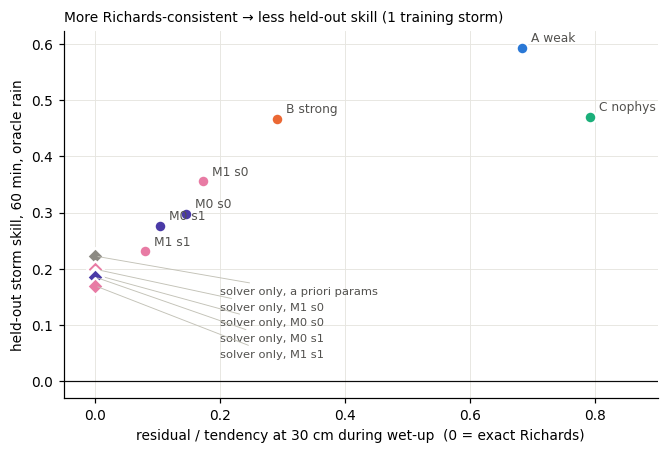

In [12]:
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': '#e6e5e0',
                     'grid.linewidth': 0.6, 'font.size': 9, 'figure.dpi': 110})
os.makedirs('figs', exist_ok=True)
FAM = {'A': '#2a78d6', 'B': '#eb6834', 'C': '#1baf7a', 'M0': '#4a3aa7', 'M1': '#e87ba4'}
fam = lambda t: t.split('_')[0]
# Fig 4: physics consistency vs held-out skill
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for t in models:
    x, y = summ.loc[t, 'wet-up |R|/|dθ/dt|'], summ.loc[t, 'net: held-out mean (s1,3-6)']
    ax.scatter(x, y, s=60, color=FAM[fam(t)], edgecolor='white', linewidth=1.5, zorder=3)
    ax.annotate(t.replace('_', ' '), (x, y), xytext=(6, 4), textcoords='offset points', fontsize=8, color='#52514e')
sv = sorted(['M0_s0', 'M0_s1', 'M1_s0', 'M1_s1', 'apriori'], key=lambda t: -sol.loc[HELD, t].mean())
for r, t in enumerate(sv):
    y = sol.loc[HELD, t].mean()
    ax.scatter(0, y, s=60, marker='D', color=FAM.get(fam(t), '#8c8a83'), edgecolor='white', linewidth=1.5, zorder=3)
    ly = 0.16 - r * 0.028                       # stacked label column, leader line to the point
    ax.annotate(('solver only, ' + t.replace('_', ' ')) if t != 'apriori' else 'solver only, a priori params',
                (0, y), xytext=(0.2, ly), textcoords='data', fontsize=7.5, color='#52514e', va='center',
                arrowprops=dict(arrowstyle='-', color='#c3c2b7', lw=0.6))
ax.set_xlabel('residual / tendency at 30 cm during wet-up  (0 = exact Richards)')
ax.set_ylabel('held-out storm skill, 60 min, oracle rain')
ax.set_title('More Richards-consistent → less held-out skill (1 training storm)', fontsize=9, loc='left')
ax.axhline(0, color='#0b0b0b', lw=0.8); ax.set_xlim(-0.05, 0.9)
fig.tight_layout(); fig.savefig('figs/fig4_physics_vs_skill.png', dpi=200); plt.show()

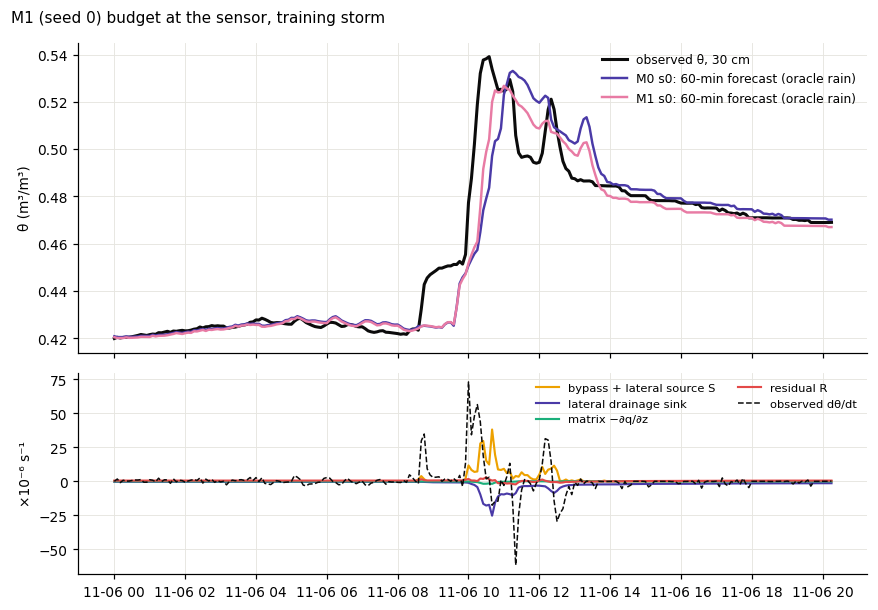

In [13]:
# Fig 5: training storm, M0 vs M1 60-min forecasts and M1 budget terms at 30 cm
w = win0; t = w['t']; sel = (t >= S108.start[0] - pd.Timedelta('3h')) & (t <= S108.end[0] + pd.Timedelta('6h'))
fig, ax = plt.subplots(2, 1, figsize=(8, 5.6), sharex=True, gridspec_kw=dict(height_ratios=[2, 1.3]))
ax[0].plot(t[sel], w['obs'].numpy()[sel], color='#0b0b0b', lw=2, label='observed θ, 30 cm')
for tag, col in [('M0_s0', FAM['M0']), ('M1_s0', FAM['M1'])]:
    r = evaluate(models[tag], w, oracle=True); idx = r['idx'].numpy(); pred = r['traj'][:, 11, I_OBS].numpy()
    tt = t[idx + 12]; ok = (tt >= t[sel][0]) & (tt <= t[sel][-1])
    ax[0].plot(tt[ok], pred[ok], color=col, lw=1.6, label=f'{tag.replace("_", " ")}: 60-min forecast (oracle rain)')
ax[0].set_ylabel('θ (m³/m³)'); ax[0].legend(frameon=False, fontsize=8)
m = models['M1_s0']; b = BUD['M1_s0']; A = b['A']; drv = b['drv']
with torch.no_grad():
    th1, q0, S = m(A[:-1], drv[:-1]); R, dthdt, div, Ss = residual(m.phys, A[:-1], th1, q0, S)
    sink = -(m.phys.p('lam_out') * m.phys.K(th1))
s1 = sel[1:]
for v, lab, col in [(Ss[:, I_OBS], 'bypass + lateral source S', '#eda100'), (sink[:, I_OBS], 'lateral drainage sink', '#4a3aa7'),
                    (div[:, I_OBS], 'matrix −∂q/∂z', '#1baf7a'), (R[:, I_OBS], 'residual R', '#e34948')]:
    ax[1].plot(t[1:][s1], v.numpy()[s1] * 1e6, color=col, lw=1.4, label=lab)
ax[1].plot(t[1:][s1], np.diff(w['obs'].numpy())[s1] / DT * 1e6, color='#0b0b0b', lw=1, ls='--', label='observed dθ/dt')
ax[1].set_ylabel('×10⁻⁶ s⁻¹'); ax[1].legend(frameon=False, fontsize=7.5, ncol=2)
fig.suptitle('M1 (seed 0) budget at the sensor, training storm', x=0.01, ha='left', fontsize=10)
fig.tight_layout(); fig.savefig('figs/fig5_m1_budget.png', dpi=200); plt.show()

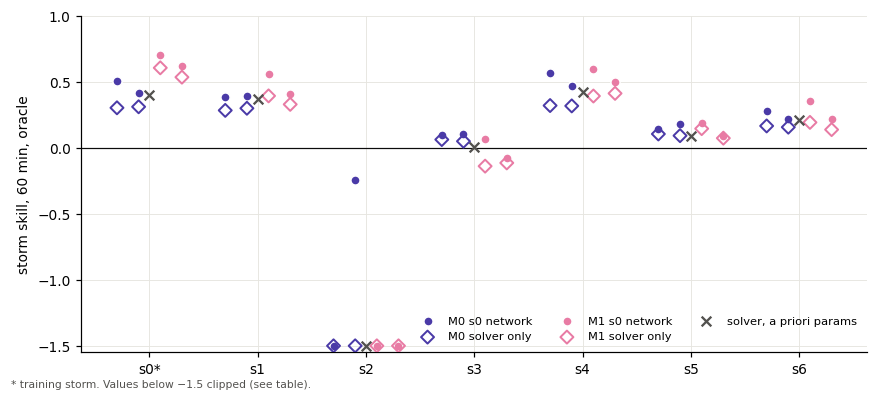

In [14]:
# Fig 6: per-storm held-out skill, network vs physics-only solver (oracle, 60 min)
fig, ax = plt.subplots(figsize=(8, 3.6))
xs = np.arange(7); off = {'M0_s0': -0.3, 'M0_s1': -0.1, 'M1_s0': 0.1, 'M1_s1': 0.3}
for tg, dx in off.items():
    ax.scatter(xs + dx, net[tg].clip(-1.5, 1), s=36, color=FAM[fam(tg)], edgecolor='white', linewidth=1, label=f'{tg.replace("_", " ")} network' if tg.endswith('s0') else None, zorder=3)
    ax.scatter(xs + dx, sol[tg].clip(-1.5, 1), s=36, marker='D', facecolor='none', edgecolor=FAM[fam(tg)], linewidth=1.3, label=f'{fam(tg)} solver only' if tg.endswith('s0') else None, zorder=3)
ax.scatter(xs, sol['apriori'].clip(-1.5, 1), s=40, marker='x', color='#52514e', label='solver, a priori params', zorder=3)
ax.axhline(0, color='#0b0b0b', lw=0.8); ax.set_ylim(-1.55, 1); ax.set_xticks(xs); ax.set_xticklabels([f's{i}' + ('*' if i == 0 else '') for i in xs])
ax.set_ylabel('storm skill, 60 min, oracle'); ax.legend(frameon=False, fontsize=7.5, ncol=3, loc='lower right')
fig.text(0.01, 0.01, '* training storm. Values below −1.5 clipped (see table).', fontsize=7, color='#52514e')
fig.tight_layout(); fig.savefig('figs/fig6_net_vs_solver.png', dpi=200); plt.show()